In [2]:
from typing import Any

import torch
import torch.nn as nn
from PIL.ImageQt import rgb
from huggingface_hub import trigger_scheduled_job


class ODEFunc(nn.Module):
    """dh/dt = f'(x) 에서 f'(x)를 의미하는 함수의 역할을 가지게 됨"""
    def __init__(self, hidden_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.Tanh(),
            nn.Linear(32, hidden_dim)
        )

    def forward(self, t, h):
        dh_dt = self.net(h)

        return dh_dt

In [4]:
from torchdiffeq import odeint

# ODE를 실제로 푸는 block
class ODEBlock(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, h):
        # 구할 시점을 정의
        t = torch.tensor(
            [0.0, 1.0],
            device=h.device
        )

        # func의 dh/dt 를 구해달라는 의미
        trajectory = odeint(
            self.func,
            h, t
        )

        # trajectory[0]은 h(0)
        # trajectory[-1]은 h(1)
        # t = tensor([0.0, 1.0]) 이여서
        return trajectory[-1]

In [5]:
class NeuralODEClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.ode_func = ODEFunc(hidden_dim=2)
        self.ode_block = ODEBlock(self.ode_func)

        self.classifier = nn.Linear(2, 2)

    def forward(self, x):
        # ODEFunc를 통해 [0.0 -> 1.0]으로 이동할 때의 변화량을 구함
        h = self.ode_block(x)

        logits = self.classifier(h)

        return logits

torch.Size([1000, 2])
torch.Size([1000])


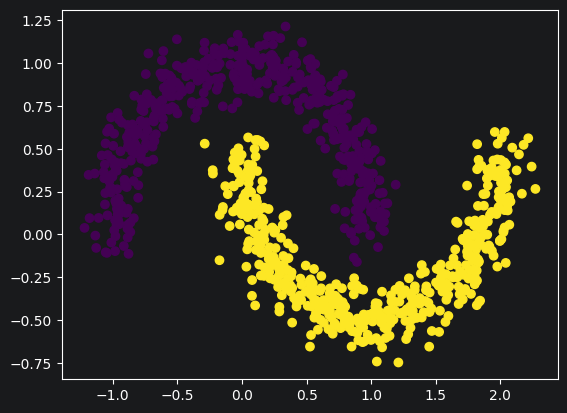

In [20]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=1_000,
    noise=0.1,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

print(X.shape)
print(y.shape)

plt.scatter(
    X[:, 0], X[:, 1],
    c=y, # cmap="RdBu_r"
)

In [22]:
func = ODEFunc(2)

sample = X[:5]

print(sample.shape)

dh_dt = func(
    torch.tensor(0.0),
    sample
)

print(dh_dt)

torch.Size([5, 2])
tensor([[-0.2150,  0.0335],
        [-0.0704,  0.1599],
        [-0.0913,  0.1415],
        [-0.3034,  0.2039],
        [-0.3996,  0.0216]], grad_fn=<AddmmBackward0>)


In [25]:
t = torch.tensor([0.0, 1.0])

trajectory = odeint(
    func,
    X, t,
    method="euler",
    options={
        "step_size": 0.05
    }
)
trajectory.shape

torch.Size([2, 1000, 2])

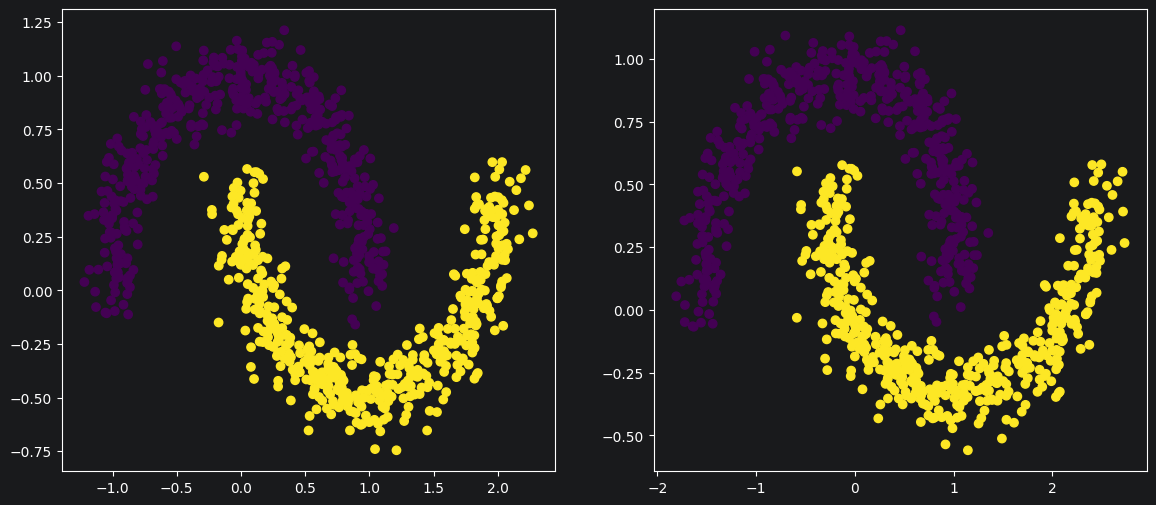

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    trajectory[0].detach()[:, 0],
    trajectory[0].detach()[:, 1],
    c=y
)

axes[1].scatter(
    trajectory[1].detach()[:, 0],
    trajectory[1].detach()[:, 1],
    c=y
)

plt.show()

In [29]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = NeuralODEClassifier().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

criterion = nn.CrossEntropyLoss()

X = X.to(DEVICE)
y = y.to(DEVICE)

for epoch in range(301):
    optimizer.zero_grad()

    logits = model(X)

    loss = criterion(logits, y)

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        pred = logits.argmax(dim=1)

        acc = (
            pred == y
        ).float().mean()

        print(epoch, loss.item(), acc.item())

0 0.7769858241081238 0.5
50 0.2261808067560196 0.9040000438690186
100 0.014450928196310997 0.9980000257492065
150 0.001204589381814003 1.0
200 0.00047972495667636395 1.0
250 0.0002837331558112055 1.0
300 0.00019212513871025294 1.0


In [32]:
X.shape

torch.Size([1000, 2])

In [47]:
t_vis = torch.linspace(0, 1, 11)

with torch.no_grad():

    trajectory = odeint(
        model.ode_func.cpu(),
        X.cpu(), t_vis,
        method="euler",
        options={
            "step_size": 0.05
        }
    )

print(trajectory.shape, trajectory.device)

torch.Size([11, 1000, 2]) cpu


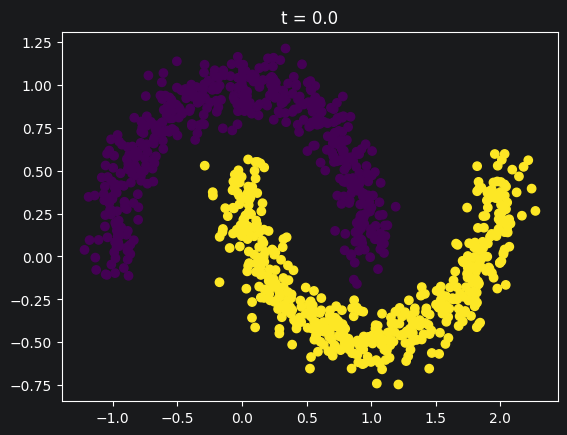

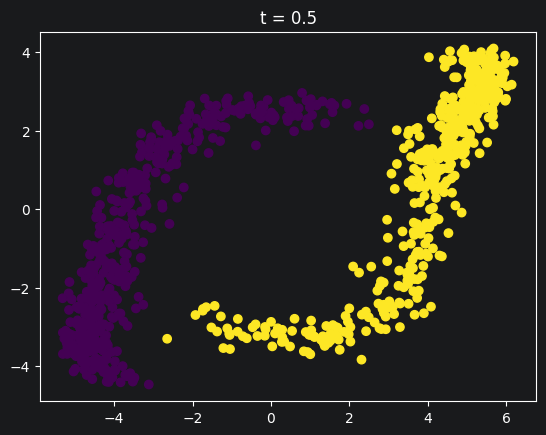

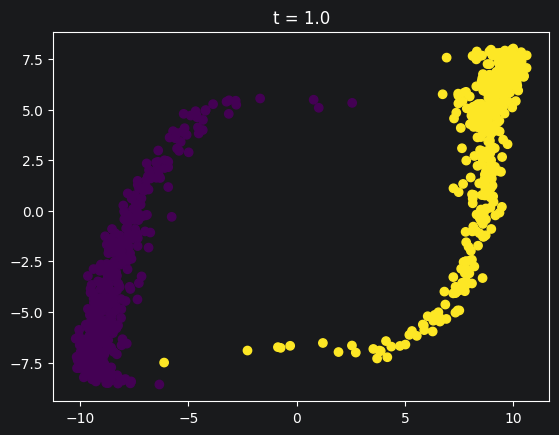

In [49]:
for i in [0, 5, 10]:

    h =  trajectory[i]

    plt.figure()

    plt.scatter(
        h[:, 0],
        h[:, 1],
        c=y.cpu()
    )

    plt.title(f"t = {t_vis[i].item():.1f}")

    plt.show()

In [51]:
next(iter(model.classifier.parameters()))

Parameter containing:
tensor([[-0.0061, -0.2524],
        [ 1.2772, -0.5400]], device='cuda:0', requires_grad=True)